In [2]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.datasets import load_diabetes
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDRegressor

# ***L2 REGULARIZATION CLASS FOR SIMPLE LINEAR REGRESSION DATA(2D)***

In [ ]:
X,y = make_regression(n_samples=350, n_features=1, n_informative=1, n_targets=1,noise=25,random_state=19)

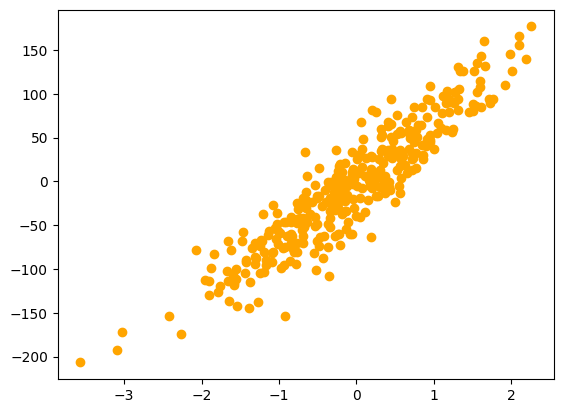

In [ ]:
plt.scatter(X,y, color='Orange')

***Scikit-learn's Linear Regression class***

In [ ]:
lr_model = LinearRegression()
lr_model.fit(X,y)
print(f'Linear Regression Class Results: b = {lr_model.intercept_} and m = {lr_model.coef_}')

Linear Regression Class Results: b = -1.1237956853460038 and m = [66.21088665]


***Scikit-learn's Ridge Regularization class***

In [ ]:
rlr_model = Ridge(alpha=10)
rlr_model.fit(X,y)
print(f'Ridge Regression Class Results: b = {rlr_model.intercept_} and m = {rlr_model.coef_}')

Ridge Regression Class Results: b = -1.2377188638976118 and m = [64.23911305]


***User defined class for Ridge Regularization(L2)***

In [ ]:
class Ridge_regularization:
  def __init__(self, alpha):
    self.alpha = alpha
    self.m = 0
    self.b = 0

  def fit(self, X_train, y_train):
    num = 0
    den = 0
    for i in range(X_train.shape[0]):
      num = num + ((X_train[i] - X_train.mean()) * (y_train[i] - y_train.mean()))
      den = den + ((X_train[i] - X_train.mean()) * (X_train[i] - X_train.mean()))

    self.m = num / (den + self.alpha)
    self. b = y_train.mean() - (self.m * X_train.mean())

    print(f'User defined Ridge regression class: m = {self.m} and b = {self.b}')

  def predict(self, X_test):
    return self.b + (self.m * X_test)

In [ ]:
ridge = Ridge_regularization(alpha=10)
ridge.fit(X,y)

User defined Ridge regression class: m = [64.23911305] and b = [-1.23771886]


# ***L2 REGULARIZATION CLASS FOR MULTIPLE LINEAR REGRESSION DATA(N-D)***

In [ ]:
X,y = load_diabetes(return_X_y=True)
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=4)

***Scikit-learn's Ridge Regularization class***

In [ ]:
rlr_model2 = Ridge(alpha=10, solver='cholesky')
rlr_model2.fit(X_train,y_train)
print(f'Ridge Regression Class Results: b = {rlr_model2.intercept_} and m = {rlr_model2.coef_}')

Ridge Regression Class Results: b = 151.60854821587688 and m = [ 19.73816861  -2.31650264  62.15929363  49.54602923  18.92716443
  12.45739602 -39.60091202  42.81978891  61.57115822  35.24731451]


***Scikit-learn's Linear Regression class***

In [ ]:
lr_model2 = LinearRegression()
lr_model2.fit(X_train,y_train)
print(f'Linear Regression Class Results: b = {lr_model2.intercept_} and m = {lr_model2.coef_}')

Linear Regression Class Results: b = 151.1466544656964 and m = [  33.40954056 -292.24112825  481.08002807  369.05716136 -966.32463944
  589.771093    232.59825938  288.32164654  802.69901575   37.81345763]


***User defined class for Ridge Regularization(L2)***

In [ ]:
class ridge_regularization:
    def __init__(self,alpha=0.1):
        self.alpha = alpha
        self.coef_ = None
        self.intercept_ = None

    def fit(self,X_train,y_train):

        X_train = np.insert(X_train,0,1,axis=1)
        I = np.identity(X_train.shape[1])
        I[0][0] = 0
        result = np.linalg.inv(np.dot(X_train.T,X_train) + self.alpha * I).dot(X_train.T).dot(y_train)
        self.intercept_ = result[0]
        self.coef_ = result[1:]
        print(f'User defined Ridge regression class: m = {self.coef_} and b = {self.intercept_[0]}')

    def predict(self,X_test):
        return np.dot(X_test,self.coef_) + self.intercept_

In [ ]:
ridge = Ridge_regularization(alpha=10)
ridge.fit(X_train,y_train)

User defined Ridge regression class: m = [ 25.186702     2.81913629  69.85653207  56.80042302  26.8150428
  20.30723785 -47.18373774  53.51352334  71.04369545  43.59560235] and b = [151.63623261 151.63223224 151.64422168 151.64188663 151.63652384
 151.63535994 151.62328937 151.64129878 151.644434   151.63952499]


# ***L2 REGULARIZATION CLASS USING GRADIENT DESCENT(N-D)***

In [3]:
X,y = load_diabetes(return_X_y=True)
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=4)

***Sklearn's Stochastic gradient descent class***

In [7]:
reg = SGDRegressor(penalty='l2',max_iter=500,eta0=0.1,learning_rate='constant',alpha=0.001)
reg.fit(X_train,y_train)
print(reg.coef_)
print(reg.intercept_)
y_pred = reg.predict(X_test)
print("R2 score",r2_score(y_test,y_pred))

[  46.76118298 -156.28010771  368.24738494  268.41648372   -6.8078553
  -57.600286   -169.91879003  136.59822769  331.11208114   95.33037123]
[149.8527951]
R2 score 0.4535065439693159


***Sklearn's ridge regression class***

In [10]:
reg = Ridge(alpha=0.001, max_iter=500,solver='sparse_cg')
reg.fit(X_train,y_train)
print(reg.coef_)
print(reg.intercept_)
y_pred = reg.predict(X_test)
print("R2 score",r2_score(y_test,y_pred))

[  34.52192544 -290.84084076  482.40181344  368.0678662  -852.44873179
  501.59160336  180.11115788  270.76333979  759.73534372   37.4913546 ]
151.10198517439466
R2 score 0.46250101619914563


***custom user defined Gradient descent ridge regression class***

In [12]:
class Ridge_regularization_GD:

    def __init__(self,epochs,learning_rate,alpha):

        self.learning_rate = learning_rate
        self.epochs = epochs
        self.alpha = alpha
        self.coef_ = None
        self.intercept_ = None

    def fit(self,X_train,y_train):

        self.coef_ = np.ones(X_train.shape[1])
        self.intercept_ = 0
        thetha = np.insert(self.coef_,0,self.intercept_)

        X_train = np.insert(X_train,0,1,axis=1)

        for i in range(self.epochs):
            thetha_der = np.dot(X_train.T,X_train).dot(thetha) - np.dot(X_train.T,y_train) + self.alpha*thetha
            thetha = thetha - self.learning_rate*thetha_der

        self.coef_ = thetha[1:]
        self.intercept_ = thetha[0]

    def predict(self,X_test):

        return np.dot(X_test,self.coef_) + self.intercept_

In [13]:
reg = Ridge_regularization_GD(epochs=500,alpha=0.001,learning_rate=0.005)
reg.fit(X_train,y_train)
print(reg.coef_)
print(reg.intercept_)
y_pred = reg.predict(X_test)
print("R2 score",r2_score(y_test,y_pred))

[  46.65050914 -221.3750037   452.12080647  325.54248128  -29.09464178
  -96.47517735 -190.90017011  146.32900372  400.80267299   95.09048094]
150.86975316713472
R2 score 0.4738018280260913
